In [2]:
import torch
import json
import datasets as hf_datasets
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm

from custom_datasets.qm9 import QM9Dataset
from utils.tokenizer import VocabTokenizer
from visualize_dataset import plot_molecule

/home/krojas/Documents/Research/Variable-Length-Diffusion/Variable-Length-Diffusion-Toy/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
tokenizer = VocabTokenizer(vocab={'H', 'C', 'N', 'O', 'F'})

In [4]:
qm9_dataset = QM9Dataset(tokenizer)

for i in range(100):
    idx = np.random.randint(0, len(qm9_dataset))
    elem = qm9_dataset[idx]
    print(tokenizer.decode(elem['y']))
    print('--------------------------------')


CNCCNNCCNHHHHHH
--------------------------------
OCOCOCCCNHHHHHHH
--------------------------------
COCCCCCCOHHHHHHHHHH
--------------------------------
CCCCOCCCOHHHHHHHH
--------------------------------
CCCCCCCOCHHHHHHHHHHHH
--------------------------------
CCCCCCCCCHHHHHHHHHHHH
--------------------------------
CCOCCCCCCHHHHHHHHHHHH
--------------------------------
NCCCCCOCNHHHHHHHHHH
--------------------------------
CCCCCCCOCHHHHHHHHHHHH
--------------------------------
CCCOCCOCOHHHHHHHHHH
--------------------------------
CCOCCNCCCHHHHHHHHHHH
--------------------------------
COCCCOCNOHHHHHHH
--------------------------------
CCCCCCCCCHHHHHHHHHH
--------------------------------
CCOCCNNCOHHHHHH
--------------------------------
CNCCCCCNHHHHHH
--------------------------------
OCCCCCOCOHHHHHH
--------------------------------
OCCCCOCCOHHHHHHHH
--------------------------------
CNCCCOCOCHHHHHHHHH
--------------------------------
CNCCCCCCOHHHHHHHHH
--------------------------------
CCCOCCOCCHHHH

In [5]:
max_atoms_for_plot = 8
fixed_rotation_seed = 7

raw_qm9 = qm9_dataset.qm9_dataset
candidate_indices = [
    i for i in range(len(raw_qm9))
    if len(raw_qm9[i]['original_atomic_symbols']) <= max_atoms_for_plot
]
if len(candidate_indices) == 0:
    raise ValueError(f'No QM9 sample found with <= {max_atoms_for_plot} atoms.')

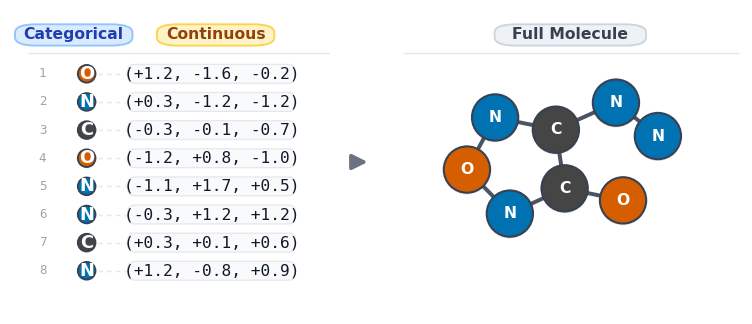

Saved to figures/qm9_multimodal_representation_95.[png|pdf]
Reproducible: sample_idx=21457, fixed_rotation_seed=13


In [6]:
from pathlib import Path
from matplotlib.patches import FancyBboxPatch, Circle
from matplotlib.lines import Line2D
from visualize_dataset import _get_bonds_via_openbabel

# ── Gray palette (Material Design–style) ──
G50 = '#F9FAFB'
G200 = '#E5E7EB'
G400 = '#9CA3AF'
G500 = '#6B7280'
G700 = '#374151'
G900 = '#111827'

# ── Colorblind-safe palette (Wong 2011 adapted) ──
ATOM_CLR = {
    'H': '#999999',
    'C': '#454545',
    'N': '#0072B2',
    'O': '#D55E00',
    'F': '#009E73',
    'S': '#F0E442',
    'Cl': '#56B4E9',
    'P': '#E69F00',
    'Br': '#CC79A7',
}
ATOM_SZ = {
    'H': 160, 'C': 380, 'N': 380, 'O': 380, 'F': 380,
    'S': 480, 'Cl': 480, 'P': 480, 'Br': 480,
}
ATOM_R3D = {
    'H': 0.13, 'C': 0.20, 'N': 0.20, 'O': 0.20, 'F': 0.20,
    'S': 0.23, 'Cl': 0.23, 'P': 0.23, 'Br': 0.25,
}


def _tc(hex_c):
    c = hex_c.lstrip('#')
    lum = 0.299 * int(c[:2], 16) + 0.587 * int(c[2:4], 16) + 0.114 * int(c[4:6], 16)
    return '#FFFFFF' if lum < 140 else '#111111'


def _compute_row_positions(n, target_row_step=0.105, y_bottom=0.13, y_top_cap=0.80):
    if n == 1:
        return np.array([0.46])
    row_step = target_row_step
    y_top = y_bottom + row_step * (n - 1)
    if y_top > y_top_cap:
        row_step = (y_top_cap - y_bottom) / (n - 1)
        y_top = y_top_cap
    return np.array([y_top - i * row_step for i in range(n)])


def plot_qm9_multimodal_representation(
    *,
    raw_sample=None,
    symbols=None,
    positions=None,
    sample_idx=None,
    fixed_rotation_seed=13,
    out_stem='figures/qm9_multimodal_representation',
    save_formats=('png', 'pdf'),
    figsize=(5.0, 2.0),
    dpi=300,
    show=True,
    save=True,
    pad_inches=0.005,
    view_elev=5,
    view_azim=35,
    molecule_spread=1.16,
    atom_size_scale=1.3,
    bond_linewidth=1.9,
    target_row_step=0.105,
    y_bottom=0.22,
    y_top_cap=0.80,
):
    """Create multimodal token + 3D molecule figure from one molecule."""
    if raw_sample is not None:
        symbols = list(raw_sample['original_atomic_symbols'])
        positions = np.array(raw_sample['original_pos'], dtype=float)
    elif symbols is None or positions is None:
        raise ValueError('Provide either raw_sample OR both symbols and positions.')
    else:
        symbols = list(symbols)
        positions = np.array(positions, dtype=float)

    positions = positions.copy()
    positions -= positions.mean(axis=0, keepdims=True)

    rng = np.random.default_rng(fixed_rotation_seed)
    q, _ = np.linalg.qr(rng.standard_normal((3, 3)))
    if np.linalg.det(q) < 0:
        q[:, -1] *= -1
    positions = positions @ q

    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Helvetica Neue', 'Helvetica', 'Arial', 'DejaVu Sans'],
    })

    fig = plt.figure(figsize=figsize, facecolor='white', dpi=150)
    ax_tok = fig.add_axes([0.002, 0.0, 0.445, 0.98])
    ax_arr = fig.add_axes([0.447, 0.0, 0.033, 0.98])
    ax_mol = fig.add_axes([0.480, 0.0, 0.518, 0.98], projection='3d')

    # PANEL A — Multimodal token stream
    ax_tok.set_xlim(0, 1)
    ax_tok.set_ylim(0, 1)
    ax_tok.set_aspect('equal')
    ax_tok.axis('off')

    # Left pane keeps only top modality badges and divider (no bottom title).
    # Draw all top badges in figure coordinates for exact vertical alignment.

    tok_x0, tok_w = 0.002, 0.445
    cat_center_tok, cont_center_tok = 0.22, 0.68
    cat_w_tok, cont_w_tok = 0.325, 0.325

    # Align all three badges by their top edge
    top_badge_h_fig = 0.059
    top_badge_top_fig = 0.943
    top_badge_y_fig = top_badge_top_fig - top_badge_h_fig

    cat_center_fig = tok_x0 + tok_w * cat_center_tok
    cont_center_fig = tok_x0 + tok_w * cont_center_tok
    cat_w_fig = tok_w * cat_w_tok
    cont_w_fig = tok_w * cont_w_tok

    cat_badge = FancyBboxPatch(
        (cat_center_fig - cat_w_fig / 2, top_badge_y_fig), cat_w_fig, top_badge_h_fig,
        boxstyle='round,pad=0.006,rounding_size=0.028',
        facecolor='#DBEAFE', edgecolor='#93C5FD', linewidth=0.9,
        transform=fig.transFigure,
        clip_on=False,
    )
    fig.patches.append(cat_badge)
    fig.text(cat_center_fig, top_badge_y_fig + top_badge_h_fig / 2, 'Categorical', fontsize=7.5, fontweight='semibold',
             color='#1E40AF', ha='center', va='center')

    cont_badge = FancyBboxPatch(
        (cont_center_fig - cont_w_fig / 2, top_badge_y_fig), cont_w_fig, top_badge_h_fig,
        boxstyle='round,pad=0.006,rounding_size=0.028',
        facecolor='#FEF3C7', edgecolor='#FCD34D', linewidth=0.9,
        transform=fig.transFigure,
        clip_on=False,
    )
    fig.patches.append(cont_badge)
    fig.text(cont_center_fig, top_badge_y_fig + top_badge_h_fig / 2, 'Continuous', fontsize=7.5, fontweight='semibold',
             color='#92400E', ha='center', va='center')

    # Single divider y in figure coords so left and right dividers align
    divider_y_fig = 0.00 + 0.872 * 0.98
    fig.add_artist(Line2D([tok_x0 + 0.04 * tok_w, tok_x0 + 0.94 * tok_w], [divider_y_fig, divider_y_fig],
                         transform=fig.transFigure, color='#E5E7EB', linewidth=0.7, solid_capstyle='round'))

    max_display = 5
    n_display = min(max_display, len(symbols))
    n_rows = n_display + (1 if len(symbols) > max_display else 0)
    ys = _compute_row_positions(
        n_rows,
        target_row_step=target_row_step,
        y_bottom=y_bottom,
        y_top_cap=y_top_cap,
    )

    for i, (sym, y) in enumerate(zip(symbols[:n_display], ys[:n_display])):
        fc = ATOM_CLR.get(sym, '#888888')
        tc = _tc(fc)
        xi, yi, zi = positions[i]

        ax_tok.text(0.025, y, str(i + 1), fontsize=6, color=G400,
                    ha='center', va='center', family='monospace')

        circ = Circle((0.22, y), 0.030, linewidth=0.9, edgecolor=G700, facecolor=fc,
                      transform=ax_tok.transAxes, zorder=3)
        ax_tok.add_patch(circ)
        ax_tok.text(0.22, y, sym, fontsize=8.5, fontweight='bold', color=tc,
                    ha='center', va='center', zorder=4)

        ax_tok.plot([0.26, 0.36], [y, y], color=G200, lw=0.7, ls=(0, (3, 3)))

        pill = FancyBboxPatch((0.37, y - 0.027), 0.56, 0.054,
                              boxstyle='round,pad=0.005,rounding_size=0.024',
                              facecolor=G50, edgecolor=G200, linewidth=0.6,
                              transform=ax_tok.transAxes, zorder=2)
        ax_tok.add_patch(pill)
        ax_tok.text(0.68, y, f'({xi:+.1f}, {yi:+.1f}, {zi:+.1f})',
                    fontsize=7.8, family='monospace', color=G900,
                    ha='center', va='center', zorder=3)

    if len(symbols) > max_display:
        y_ellipsis = ys[n_display]
        ax_tok.text(0.68, y_ellipsis, '...', fontsize=9, color=G500,
                    ha='center', va='center', zorder=3)

    # CONNECTOR
    ax_arr.set_xlim(0, 1)
    ax_arr.set_ylim(0, 1)
    ax_arr.axis('off')
    ax_arr.annotate('', xy=(0.92, 0.5), xytext=(0.08, 0.5),
                    arrowprops=dict(arrowstyle='-|>', lw=1.8, mutation_scale=15, color=G500))

    # PANEL B — 3D molecular geometry
    ax_mol.set_facecolor('white')

    # Right badge uses the same figure-level y-band as left badges.
    full_center = 0.742
    full_w = 0.19
    full_badge = FancyBboxPatch(
        (full_center - full_w / 2, top_badge_y_fig), full_w, top_badge_h_fig,
        boxstyle='round,pad=0.006,rounding_size=0.028',
        facecolor='#EEF2F7', edgecolor='#CBD5E1', linewidth=0.9,
        transform=fig.transFigure,
        clip_on=False,
    )
    fig.patches.append(full_badge)
    fig.text(full_center, top_badge_y_fig + top_badge_h_fig / 2, 'Full Molecule', fontsize=7.5, fontweight='semibold',
             color=G700, ha='center', va='center')

    fig.add_artist(Line2D([0.52, 0.965], [divider_y_fig, divider_y_fig], transform=fig.transFigure,
                          color='#E5E7EB', linewidth=0.7, solid_capstyle='round'))

    # Slightly expand the geometry and reduce marker scale to avoid visual stacking.
    pos_plot = positions.copy() * molecule_spread
    colors_3d = [ATOM_CLR.get(s, '#888') for s in symbols]
    sizes_3d = np.array([ATOM_SZ.get(s, 300) for s in symbols], dtype=float) * atom_size_scale

    bonds = _get_bonds_via_openbabel(symbols, pos_plot)
    for bi, bj in bonds:
        pi, pj = pos_plot[bi], pos_plot[bj]
        v = pj - pi
        d = np.linalg.norm(v)
        if d < 1e-8:
            continue
        u = v / d
        start = pi + u * ATOM_R3D.get(symbols[bi], 0.18)
        end = pj - u * ATOM_R3D.get(symbols[bj], 0.18)
        if np.linalg.norm(end - start) < 1e-4:
            continue
        ax_mol.plot([start[0], end[0]], [start[1], end[1]], [start[2], end[2]],
                    color=G700, linewidth=bond_linewidth, solid_capstyle='round', alpha=0.9, zorder=2)

    ax_mol.scatter(pos_plot[:, 0] - 0.015, pos_plot[:, 1] - 0.015, pos_plot[:, 2] - 0.03,
                   s=sizes_3d * 1.06, c='#111827', alpha=0.10,
                   linewidths=0, depthshade=False, zorder=1)
    ax_mol.scatter(pos_plot[:, 0], pos_plot[:, 1], pos_plot[:, 2],
                   s=sizes_3d, c=colors_3d, edgecolor=G700, linewidths=1.0,
                   alpha=1.0, depthshade=True, zorder=4)
    ax_mol.scatter(pos_plot[:, 0] - 0.020, pos_plot[:, 1] + 0.018, pos_plot[:, 2] + 0.022,
                   s=sizes_3d * 0.16, c='white', alpha=0.34,
                   linewidths=0, depthshade=False, zorder=5)

    for i, sym in enumerate(symbols):
        ax_mol.text(pos_plot[i, 0], pos_plot[i, 1], pos_plot[i, 2], sym,
                    fontsize=7.5, ha='center', va='center', zorder=6,
                    color=_tc(ATOM_CLR.get(sym, '#888')), fontweight='bold')

    mins, maxs = pos_plot.min(axis=0), pos_plot.max(axis=0)
    ctr = (mins + maxs) / 2.0
    hr = max((maxs - mins).max() / 2.0 + 0.24, 0.78)
    ax_mol.set_xlim(ctr[0] - 1.18 * hr, ctr[0] + 0.82 * hr)
    ax_mol.set_ylim(ctr[1] - hr, ctr[1] + hr)
    ax_mol.set_zlim(ctr[2] - hr, ctr[2] + hr)
    ax_mol.set_box_aspect((1, 1, 1))
    ax_mol.set_proj_type('persp')
    ax_mol.view_init(elev=view_elev, azim=view_azim)

    ax_mol.grid(False)
    ax_mol.set_xticks([])
    ax_mol.set_yticks([])
    ax_mol.set_zticks([])
    for axis in (ax_mol.xaxis, ax_mol.yaxis, ax_mol.zaxis):
        axis.pane.set_edgecolor((0, 0, 0, 0))
        axis.pane.set_facecolor((1, 1, 1, 0))
    ax_mol.set_axis_off()

    out_paths = []
    if save:
        for fmt in save_formats:
            out = Path(f'{out_stem}.{fmt}')
            out.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(out, dpi=dpi, bbox_inches='tight', facecolor='white', pad_inches=pad_inches)
            out_paths.append(out)

    if show:
        plt.show()

    return {
        'fig': fig,
        'axes': {'tokens': ax_tok, 'arrow': ax_arr, 'molecule': ax_mol},
        'out_paths': out_paths,
        'sample_idx': sample_idx,
        'fixed_rotation_seed': fixed_rotation_seed,
    }


# Example usage
for i in list([95]):
    sample_idx = candidate_indices[i]
    raw_sample = raw_qm9[sample_idx]
    fixed_rotation_seed = 13

    result = plot_qm9_multimodal_representation(
        raw_sample=raw_sample,
        sample_idx=sample_idx,
        fixed_rotation_seed=fixed_rotation_seed,
    )

    if result['out_paths']:
        stem = result['out_paths'][0].with_suffix('')
        stem = f'{stem}_{i}'
        formats = '|'.join(p.suffix.lstrip('.') for p in result['out_paths'])
        print(f'Saved to {stem}.[{formats}]')
    print(f'Reproducible: sample_idx={sample_idx}, fixed_rotation_seed={fixed_rotation_seed}')

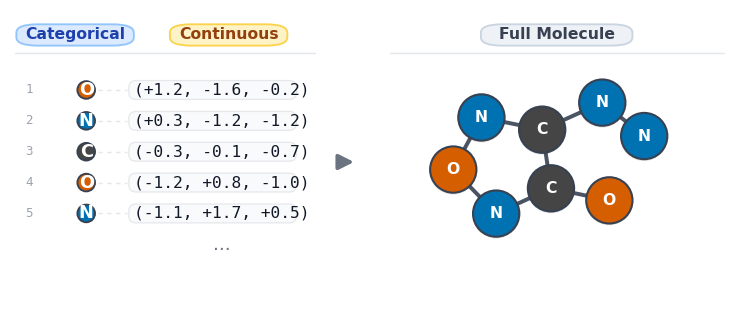

Saved to figures/qm9_multimodal_representation_95.[png|pdf]
Reproducible: sample_idx=21457, fixed_rotation_seed=13


In [9]:
from pathlib import Path
from matplotlib.patches import FancyBboxPatch, Circle
from matplotlib.lines import Line2D
from visualize_dataset import _get_bonds_via_openbabel

# ── Gray palette (Material Design–style) ──
G50 = '#F9FAFB'
G200 = '#E5E7EB'
G400 = '#9CA3AF'
G500 = '#6B7280'
G700 = '#374151'
G900 = '#111827'

# ── Colorblind-safe palette (Wong 2011 adapted) ──
ATOM_CLR = {
    'H': '#999999',
    'C': '#454545',
    'N': '#0072B2',
    'O': '#D55E00',
    'F': '#009E73',
    'S': '#F0E442',
    'Cl': '#56B4E9',
    'P': '#E69F00',
    'Br': '#CC79A7',
}
ATOM_SZ = {
    'H': 160, 'C': 380, 'N': 380, 'O': 380, 'F': 380,
    'S': 480, 'Cl': 480, 'P': 480, 'Br': 480,
}
ATOM_R3D = {
    'H': 0.13, 'C': 0.20, 'N': 0.20, 'O': 0.20, 'F': 0.20,
    'S': 0.23, 'Cl': 0.23, 'P': 0.23, 'Br': 0.25,
}


def _tc(hex_c):
    c = hex_c.lstrip('#')
    lum = 0.299 * int(c[:2], 16) + 0.587 * int(c[2:4], 16) + 0.114 * int(c[4:6], 16)
    return '#FFFFFF' if lum < 140 else '#111111'


def _compute_row_positions(n, target_row_step=0.105, y_bottom=0.13, y_top_cap=0.80):
    if n == 1:
        return np.array([0.46])
    row_step = target_row_step
    y_top = y_bottom + row_step * (n - 1)
    if y_top > y_top_cap:
        row_step = (y_top_cap - y_bottom) / (n - 1)
        y_top = y_top_cap
    return np.array([y_top - i * row_step for i in range(n)])


def plot_qm9_multimodal_representation(
    *,
    raw_sample=None,
    symbols=None,
    positions=None,
    sample_idx=None,
    fixed_rotation_seed=13,
    out_stem='figures/qm9_multimodal_representation',
    save_formats=('png', 'pdf'),
    figsize=(5.0, 2.0),
    dpi=300,
    show=True,
    save=True,
    pad_inches=0.005,
    view_elev=5,
    view_azim=35,
    molecule_spread=1.16,
    atom_size_scale=1.3,
    bond_linewidth=1.9,
    target_row_step=0.105,
    y_bottom=0.22,
    y_top_cap=0.80,
):
    """Create multimodal token + 3D molecule figure from one molecule."""
    if raw_sample is not None:
        symbols = list(raw_sample['original_atomic_symbols'])
        positions = np.array(raw_sample['original_pos'], dtype=float)
    elif symbols is None or positions is None:
        raise ValueError('Provide either raw_sample OR both symbols and positions.')
    else:
        symbols = list(symbols)
        positions = np.array(positions, dtype=float)

    positions = positions.copy()
    positions -= positions.mean(axis=0, keepdims=True)

    rng = np.random.default_rng(fixed_rotation_seed)
    q, _ = np.linalg.qr(rng.standard_normal((3, 3)))
    if np.linalg.det(q) < 0:
        q[:, -1] *= -1
    positions = positions @ q

    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Helvetica Neue', 'Helvetica', 'Arial', 'DejaVu Sans'],
    })

    fig = plt.figure(figsize=figsize, facecolor='white', dpi=150)
    ax_tok = fig.add_axes([0.002, 0.0, 0.445, 0.98])
    ax_arr = fig.add_axes([0.447, 0.0, 0.033, 0.98])
    ax_mol = fig.add_axes([0.480, 0.0, 0.518, 0.98], projection='3d')

    # PANEL A — Multimodal token stream
    ax_tok.set_xlim(0, 1)
    ax_tok.set_ylim(0, 1)
    ax_tok.set_aspect('equal')
    ax_tok.axis('off')

    # Left pane keeps only top modality badges and divider (no bottom title).
    # Draw all top badges in figure coordinates for exact vertical alignment.

    tok_x0, tok_w = 0.002, 0.445
    cat_center_tok, cont_center_tok = 0.22, 0.68
    cat_w_tok, cont_w_tok = 0.325, 0.325

    # Align all three badges by their top edge
    top_badge_h_fig = 0.059
    top_badge_top_fig = 0.943
    top_badge_y_fig = top_badge_top_fig - top_badge_h_fig

    cat_center_fig = tok_x0 + tok_w * cat_center_tok
    cont_center_fig = tok_x0 + tok_w * cont_center_tok
    cat_w_fig = tok_w * cat_w_tok
    cont_w_fig = tok_w * cont_w_tok

    cat_badge = FancyBboxPatch(
        (cat_center_fig - cat_w_fig / 2, top_badge_y_fig), cat_w_fig, top_badge_h_fig,
        boxstyle='round,pad=0.006,rounding_size=0.028',
        facecolor='#DBEAFE', edgecolor='#93C5FD', linewidth=0.9,
        transform=fig.transFigure,
        clip_on=False,
    )
    fig.patches.append(cat_badge)
    fig.text(cat_center_fig, top_badge_y_fig + top_badge_h_fig / 2, 'Categorical', fontsize=7.5, fontweight='semibold',
             color='#1E40AF', ha='center', va='center')

    cont_badge = FancyBboxPatch(
        (cont_center_fig - cont_w_fig / 2, top_badge_y_fig), cont_w_fig, top_badge_h_fig,
        boxstyle='round,pad=0.006,rounding_size=0.028',
        facecolor='#FEF3C7', edgecolor='#FCD34D', linewidth=0.9,
        transform=fig.transFigure,
        clip_on=False,
    )
    fig.patches.append(cont_badge)
    fig.text(cont_center_fig, top_badge_y_fig + top_badge_h_fig / 2, 'Continuous', fontsize=7.5, fontweight='semibold',
             color='#92400E', ha='center', va='center')

    # Single divider y in figure coords so left and right dividers align
    divider_y_fig = 0.00 + 0.872 * 0.98
    fig.add_artist(Line2D([tok_x0 + 0.04 * tok_w, tok_x0 + 0.94 * tok_w], [divider_y_fig, divider_y_fig],
                         transform=fig.transFigure, color='#E5E7EB', linewidth=0.7, solid_capstyle='round'))

    max_display = 5
    n_display = min(max_display, len(symbols))
    n_rows = n_display + (1 if len(symbols) > max_display else 0)
    ys = _compute_row_positions(
        n_rows,
        target_row_step=target_row_step,
        y_bottom=y_bottom,
        y_top_cap=y_top_cap,
    )

    for i, (sym, y) in enumerate(zip(symbols[:n_display], ys[:n_display])):
        fc = ATOM_CLR.get(sym, '#888888')
        tc = _tc(fc)
        xi, yi, zi = positions[i]

        ax_tok.text(0.025, y, str(i + 1), fontsize=6, color=G400,
                    ha='center', va='center', family='monospace')

        circ = Circle((0.22, y), 0.030, linewidth=0.9, edgecolor=G700, facecolor=fc,
                      transform=ax_tok.transAxes, zorder=3)
        ax_tok.add_patch(circ)
        ax_tok.text(0.22, y, sym, fontsize=8.5, fontweight='bold', color=tc,
                    ha='center', va='center', zorder=4)

        ax_tok.plot([0.26, 0.36], [y, y], color=G200, lw=0.7, ls=(0, (3, 3)))

        pill = FancyBboxPatch((0.37, y - 0.027), 0.56, 0.054,
                              boxstyle='round,pad=0.005,rounding_size=0.024',
                              facecolor=G50, edgecolor=G200, linewidth=0.6,
                              transform=ax_tok.transAxes, zorder=2)
        ax_tok.add_patch(pill)
        ax_tok.text(0.68, y, f'({xi:+.1f}, {yi:+.1f}, {zi:+.1f})',
                    fontsize=7.8, family='monospace', color=G900,
                    ha='center', va='center', zorder=3)

    if len(symbols) > max_display:
        y_ellipsis = ys[n_display]
        ax_tok.text(0.68, y_ellipsis, '...', fontsize=9, color=G500,
                    ha='center', va='center', zorder=3)

    # CONNECTOR
    ax_arr.set_xlim(0, 1)
    ax_arr.set_ylim(0, 1)
    ax_arr.axis('off')
    ax_arr.annotate('', xy=(0.92, 0.5), xytext=(0.08, 0.5),
                    arrowprops=dict(arrowstyle='-|>', lw=1.8, mutation_scale=15, color=G500))

    # PANEL B — 3D molecular geometry
    ax_mol.set_facecolor('white')

    # Right badge uses the same figure-level y-band as left badges.
    full_center = 0.742
    full_w = 0.19
    full_badge = FancyBboxPatch(
        (full_center - full_w / 2, top_badge_y_fig), full_w, top_badge_h_fig,
        boxstyle='round,pad=0.006,rounding_size=0.028',
        facecolor='#EEF2F7', edgecolor='#CBD5E1', linewidth=0.9,
        transform=fig.transFigure,
        clip_on=False,
    )
    fig.patches.append(full_badge)
    fig.text(full_center, top_badge_y_fig + top_badge_h_fig / 2, 'Full Molecule', fontsize=7.5, fontweight='semibold',
             color=G700, ha='center', va='center')

    fig.add_artist(Line2D([0.52, 0.965], [divider_y_fig, divider_y_fig], transform=fig.transFigure,
                          color='#E5E7EB', linewidth=0.7, solid_capstyle='round'))

    # Slightly expand the geometry and reduce marker scale to avoid visual stacking.
    pos_plot = positions.copy() * molecule_spread
    colors_3d = [ATOM_CLR.get(s, '#888') for s in symbols]
    sizes_3d = np.array([ATOM_SZ.get(s, 300) for s in symbols], dtype=float) * atom_size_scale

    bonds = _get_bonds_via_openbabel(symbols, pos_plot)
    for bi, bj in bonds:
        pi, pj = pos_plot[bi], pos_plot[bj]
        v = pj - pi
        d = np.linalg.norm(v)
        if d < 1e-8:
            continue
        u = v / d
        start = pi + u * ATOM_R3D.get(symbols[bi], 0.18)
        end = pj - u * ATOM_R3D.get(symbols[bj], 0.18)
        if np.linalg.norm(end - start) < 1e-4:
            continue
        ax_mol.plot([start[0], end[0]], [start[1], end[1]], [start[2], end[2]],
                    color=G700, linewidth=bond_linewidth, solid_capstyle='round', alpha=0.9, zorder=2)

    ax_mol.scatter(pos_plot[:, 0] - 0.015, pos_plot[:, 1] - 0.015, pos_plot[:, 2] - 0.03,
                   s=sizes_3d * 1.06, c='#111827', alpha=0.10,
                   linewidths=0, depthshade=False, zorder=1)
    ax_mol.scatter(pos_plot[:, 0], pos_plot[:, 1], pos_plot[:, 2],
                   s=sizes_3d, c=colors_3d, edgecolor=G700, linewidths=1.0,
                   alpha=1.0, depthshade=True, zorder=4)
    ax_mol.scatter(pos_plot[:, 0] - 0.020, pos_plot[:, 1] + 0.018, pos_plot[:, 2] + 0.022,
                   s=sizes_3d * 0.16, c='white', alpha=0.34,
                   linewidths=0, depthshade=False, zorder=5)

    for i, sym in enumerate(symbols):
        ax_mol.text(pos_plot[i, 0], pos_plot[i, 1], pos_plot[i, 2], sym,
                    fontsize=7.5, ha='center', va='center', zorder=6,
                    color=_tc(ATOM_CLR.get(sym, '#888')), fontweight='bold')

    mins, maxs = pos_plot.min(axis=0), pos_plot.max(axis=0)
    ctr = (mins + maxs) / 2.0
    hr = max((maxs - mins).max() / 2.0 + 0.24, 0.78)
    ax_mol.set_xlim(ctr[0] - 1.18 * hr, ctr[0] + 0.82 * hr)
    ax_mol.set_ylim(ctr[1] - hr, ctr[1] + hr)
    ax_mol.set_zlim(ctr[2] - hr, ctr[2] + hr)
    ax_mol.set_box_aspect((1, 1, 1))
    ax_mol.set_proj_type('persp')
    ax_mol.view_init(elev=view_elev, azim=view_azim)

    ax_mol.grid(False)
    ax_mol.set_xticks([])
    ax_mol.set_yticks([])
    ax_mol.set_zticks([])
    for axis in (ax_mol.xaxis, ax_mol.yaxis, ax_mol.zaxis):
        axis.pane.set_edgecolor((0, 0, 0, 0))
        axis.pane.set_facecolor((1, 1, 1, 0))
    ax_mol.set_axis_off()

    out_paths = []
    if save:
        for fmt in save_formats:
            out = Path(f'{out_stem}.{fmt}')
            out.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(out, dpi=dpi, bbox_inches='tight', facecolor='white', pad_inches=pad_inches)
            out_paths.append(out)

    if show:
        plt.show()

    return {
        'fig': fig,
        'axes': {'tokens': ax_tok, 'arrow': ax_arr, 'molecule': ax_mol},
        'out_paths': out_paths,
        'sample_idx': sample_idx,
        'fixed_rotation_seed': fixed_rotation_seed,
    }


# Example usage
for i in list([95]):
    sample_idx = candidate_indices[i]
    raw_sample = raw_qm9[sample_idx]
    fixed_rotation_seed = 13

    result = plot_qm9_multimodal_representation(
        raw_sample=raw_sample,
        sample_idx=sample_idx,
        fixed_rotation_seed=fixed_rotation_seed,
    )

    if result['out_paths']:
        stem = result['out_paths'][0].with_suffix('')
        stem = f'{stem}_{i}'
        formats = '|'.join(p.suffix.lstrip('.') for p in result['out_paths'])
        print(f'Saved to {stem}.[{formats}]')
    print(f'Reproducible: sample_idx={sample_idx}, fixed_rotation_seed={fixed_rotation_seed}')

In [8]:
# Compare average KS statistic (all_samples) for Euler vs 2nd-order at checkpoint 1350
from pathlib import Path
import re
import matplotlib.pyplot as plt

results_root = Path("results")
checkpoint = "1350"

records = []
for run_dir in results_root.glob(f"results-matching-{checkpoint}-*"):
    name = run_dir.name
    # Use "split" folders as 2nd-order runs to match existing naming.
    if "euler" in name:
        method = "Euler"
    elif "split" in name:
        method = "2nd order"
    else:
        continue

    step_match = re.search(r"-(\d+)steps", name)
    if not step_match:
        continue
    steps = int(step_match.group(1))

    summary_path = run_dir / "all_samples" / "ks_statistics_summary.txt"
    if not summary_path.exists():
        continue

    lines = [line.strip() for line in summary_path.read_text().splitlines() if line.strip()]
    if not lines:
        continue

    last_line = lines[-1]  # expected like: "Average          0.9320"
    value_match = re.search(r"([0-9]*\.?[0-9]+)\s*$", last_line)
    if not value_match:
        continue
    avg_ks = float(value_match.group(1))

    records.append({"method": method, "steps": steps, "avg_ks": avg_ks, "run": name})

if not records:
    raise RuntimeError("No matching results found for checkpoint 1350.")

# Sort and print what was collected for transparency.
records = sorted(records, key=lambda r: (r["method"], r["steps"]))
for r in records:
    print(f"{r['method']:10s} | steps={r['steps']:4d} | avg={r['avg_ks']:.4f} | {r['run']}")

series = {"Euler": [], "2nd order": []}
for r in records:
    series[r["method"]].append((r["steps"], r["avg_ks"]))

plt.figure(figsize=(7, 4.5))
for method, pts in series.items():
    if not pts:
        continue
    x = [p[0] for p in pts]
    y = [p[1] for p in pts]
    plt.plot(x, y, marker="o", linewidth=2, label=method)

plt.xlabel("Sampling steps")
plt.ylabel("Average KS statistic (all_samples)")
plt.title("Checkpoint 1350: Euler vs 2nd order")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

RuntimeError: No matching results found for checkpoint 1350.